In [8]:
from google.colab import files
uploaded = files.upload()

Saving adjusted_noisy_knn_300.csv to adjusted_noisy_knn_300.csv



---

---

# Technical Breakdown of File Upload Logic

---

`from google.colab import files:`

- Logic: This line imports the `files` module from the `google.colab` library.

- Function: It gives the Python environment access to specialized tools designed to interact with your local computer's file system through the browser.

- Purpose: To enable the notebook to receive external data files that are not already stored on the Google Drive or the Colab server.

========================================================

`uploaded = files.upload():`

- Logic: This calls the `upload()` function and assigns the result to a variable named `uploaded`.

- Function: It triggers a JavaScript "Choose Files" button in the output cell. When you select a file, it reads the file's content into a dictionary where the keys are filenames and the values are the raw byte data.

- Purpose: To physically transfer the dataset from your local hard drive into the temporary storage of the Google Colab virtual machine so the code can process it.



---



---



In [237]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
df = pd.read_csv("/content/adjusted_noisy_knn_300.csv")

# 1. Remove duplicate customer records
df = df.drop_duplicates(subset=['Customer_ID'])

# 2. Handle Age and Income outliers by marking them as NaN
df.loc[(df['Age'] > 100) | (df['Age'] < 0), 'Age'] = np.nan
df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = np.nan

# 3. Impute missing values using the median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income'].median())
df['Total_Spend'] = df['Total_Spend'].fillna(df['Total_Spend'].median())

# 4. Standardize categorical text data (Gender and Device Type)
df['Gender'] = df['Gender'].str.strip().str.lower().replace({
    'm': 'Male', 'male': 'Male',
    'f': 'Female', 'female': 'Female', 'fem': 'Female'
})
df['Device_Type'] = df['Device_Type'].str.strip().str.capitalize()

# 5. Feature Engineering: Create Purchase_Volume bins
df['Purchase_Volume'] = pd.cut(df['Items_Purchased'],
                               bins=[0, 15, 35, 51],
                               labels=['Low', 'Medium', 'High'])

# 6. Integrate external tax data
region_tax_data = pd.DataFrame({
    'Store_Region': ['North', 'South', 'East', 'West'],
    'Tax_Rate': [0.05, 0.07, 0.06, 0.08]
})
df = pd.merge(df, region_tax_data, on='Store_Region', how='left')

# 7. Scaling numeric features
scaler = MinMaxScaler()
numeric_cols = ['Age', 'Annual_Income', 'Total_Spend', 'Items_Purchased',
                'Last_Logon_Days', 'Support_Calls', 'Tax_Rate']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 8. One-Hot Encoding for categorical variables
df = pd.get_dummies(df, columns=['Gender', 'Device_Type', 'Store_Region', 'Purchase_Volume'])

# 9. Drop irrelevant columns
cols_to_drop = ['Membership_Score', 'Newsletter_Sub', 'Customer_ID', 'Purchase_Date']
df_final = df.drop(columns=cols_to_drop)

# Save the prepared dataset
df_final.to_csv('cleaned_knn_data.csv', index=False)
print("Data Preparation Complete. Final shape:", df_final.shape)

Data Preparation Complete. Final shape: (286, 21)




---


---

# Technical Breakdown of Code for Data Cleaning Pipeline

---


### I. Data Loading and Initial Cleaning

 **`import pandas as pd`**, **`import numpy as np`**, **`from sklearn... import MinMaxScaler`**:
* **Logic**: Imports essential data science libraries.
* **Function**: Enables tabular data handling, mathematical operations (like `NaN` creation), and feature scaling.
* **Purpose**: To provide the toolkit necessary for data manipulation and normalization.


**`df = pd.read_csv("/content/adjusted_noisy_knn_300.csv")`**:
* **Logic**: Reads the dataset into a DataFrame.
* **Function**: Loads the raw "noisy" data from the specified path.
* **Purpose**: To bring the data into memory for cleaning.


**`df = df.drop_duplicates(subset=['Customer_ID'])`**:
* **Logic**: Identifies and removes rows where `Customer_ID` is repeated.
* **Function**: Cleans redundancy in the dataset.
* **Purpose**: To ensure each data point represents a unique individual, preventing biased modeling.

================================================================================

### II. Handling Anomalies and Missing Values

**`df.loc[(df['Age'] > 100) | (df['Age'] < 0), 'Age'] = np.nan`**:
* **Logic**: Uses conditional indexing to find impossible `Age` values.
* **Function**: Converts physically impossible outliers into null values (`NaN`).
* **Purpose**: To remove incorrect data that would skew distance-based k-NN calculations.


**`df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = np.nan`**:
* **Logic**: Targets negative values in the income column.
* **Function**: Standardizes error handling for financial data.
* **Purpose**: To ensure variables like income remain realistic and non-negative.


**`df['Age'] = df['Age'].fillna(df['Age'].median())` (and others)**:
* **Logic**: Replaces `NaN` or null entries with the middle value of the column.
* **Function**: Performs "Imputation" to fill in missingness.
* **Purpose**: To retain rows that would otherwise be dropped, maintaining a larger dataset for training.

================================================================================

### III. Categorical Standardization and Feature Engineering

**`df['Gender'] = df['Gender'].str.strip().str.lower().replace(...)`**:
* **Logic**: Cleans whitespace, normalizes casing, and maps various abbreviations (e.g., 'fem') to a single format.
* **Function**: Resolves inconsistency in textual data.
* **Purpose**: To ensure the model recognizes 'Male' and 'male' as the same category.


**`df['Purchase_Volume'] = pd.cut(...)`**:
* **Logic**: Groups the numeric `Items_Purchased` column into three specific ranges (bins).
* **Function**: Transforms a continuous number into a categorical label ('Low', 'Medium', 'High').
* **Purpose**: To simplify patterns for the model to learn broader behavior groups.


**`df = pd.merge(df, region_tax_data, on='Store_Region', how='left')`**:
* **Logic**: Combines the main dataset with a new table using `Store_Region` as the key.
* **Function**: Performs a relational join to add `Tax_Rate` information.
* **Purpose**: To enrich the data with relevant external information that might influence purchase behavior.

================================================================================

### IV. Normalization and Encoding

**`scaler = MinMaxScaler()` / `scaler.fit_transform(...)`:**
* **Logic**: Rescales numeric values to a fixed range, typically between 0 and 1.
* **Function**: Addresses "Scale Imbalance" between large numbers (Annual Income) and small ones (Support Calls).
* **Purpose**: To prevent columns with higher magnitudes from dominating the k-NN distance metric.


**`df = pd.get_dummies(...)`**:
* **Logic**: Creates new binary (0 or 1) columns for every category in the specified text columns.
* **Function**: Performs One-Hot Encoding.
* **Purpose**: To convert text labels into a numeric format that mathematical algorithms can process.


**`df_final = df.drop(columns=cols_to_drop)`**:
* **Logic**: Deletes specified columns that are no longer needed.
* **Function**: Removes identifiers and noisy features like `Customer_ID` and `Purchase_Date`.
* **Purpose**: To refine the feature set to only the most relevant predictors.



---

---

In [238]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the raw dataset
df_raw = pd.read_csv('/content/adjusted_noisy_knn_300.csv')

# Baseline Preparation: Keep only numeric columns and drop NaN rows
df_naive = df_raw.select_dtypes(include=['number']).dropna()

# Separate Features (X) and Target (y)
X_naive = df_naive.drop(columns=['Purchase_Likelihood'])
y_naive = df_naive['Purchase_Likelihood']

# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X_naive, y_naive, test_size=0.2, random_state=42)

# Train k-NN (k=5)
knn_naive = KNeighborsClassifier(n_neighbors=5)
knn_naive.fit(X_train, y_train)

# Evaluate
y_pred = knn_naive.predict(X_test)
print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("Baseline Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Baseline Accuracy: 42.86%
Baseline Confusion Matrix:
 [[3 1]
 [7 3]]


---

---

# Technical Breakdown of Code for Implementing kNN with raw dataset


---


### I. Model Configuration and Data Loading

**`import pandas as pd` / `from sklearn... import ...`:**
* **Logic**: Imports the data manipulation library and specific scikit-learn modules for splitting data, the k-NN algorithm, and performance metrics.
* **Function**: Provides the environment with the necessary tools to build, train, and test a machine learning model.
* **Purpose**: To establish the coding framework for the baseline performance test.


**`df_raw = pd.read_csv('/content/adjusted_noisy_knn_300.csv')`**:
* **Logic**: Loads the original dataset into the `df_raw` variable.
* **Function**: Accesses the raw, uncleaned CSV data from the temporary Colab storage.
* **Purpose**: To establish the starting point for the "naive" run before any advanced cleaning occurs.

================================================================================

### II. Minimalist "Naive" Data Preparation

**`df_naive = df_raw.select_dtypes(include=['number']).dropna()`**:
* **Logic**: This chained command first filters the dataset to keep only numeric columns (integers and floats), then immediately removes any rows containing null values.
* **Function**: Performs a "bare minimum" cleaning by discarding all text/categorical "noise" and incomplete records.
* **Purpose**: To create a functional (though likely lower-quality) dataset that the mathematical k-NN algorithm can process without crashing.


**`X_naive = df_naive.drop(columns=['Purchase_Likelihood'])`**:
* **Logic**: Creates the feature set by excluding the target column.
* **Function**: Isolates the independent variables (the inputs) used to make predictions.
* **Purpose**: To prepare the  input matrix for the model.


**`y_naive = df_naive['Purchase_Likelihood']`**:
* **Logic**: Assigns the `Purchase_Likelihood` column to the variable .
* **Function**: Isolates the dependent variable (the labels) that the model is trying to learn.
* **Purpose**: To provide the "ground truth" for training and evaluation.

================================================================================

### III. Training and Evaluation

**`X_train, X_test, y_train, y_test = train_test_split(...)`**:
* **Logic**: Randomly divides the data, with 20% reserved for testing and 80% for training.
* **Function**: Ensures the model is tested on "unseen" data to gauge its real-world accuracy.
* **Purpose**: To prevent overfitting and validate model performance reliably.


**`knn_naive = KNeighborsClassifier(n_neighbors=5)`**:
* **Logic**: Initializes the k-NN classifier with the parameter .
* **Function**: Sets the model to look at the 5 nearest neighbors to decide a classification.
* **Purpose**: To fulfill the baseline requirement of the exercise ().


**`knn_naive.fit(X_train, y_train)`**:
* **Logic**: Executes the training process using the training subset.
* **Function**: Map the relationship between the numeric features and the purchase labels.
* **Purpose**: To build the predictive "knowledge" of the baseline model.


**`y_pred = knn_naive.predict(X_test)`**:
* **Logic**: Generates predictions for the test feature set.
* **Function**: Applies the learned model to the testing data.
* **Purpose**: To gather the predictions needed for accuracy calculation.


---

---

In [239]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load the prepared dataset
df_prepared = pd.read_csv("cleaned_knn_data.csv")

# Safety Check: Handle any remaining NaNs
if df_prepared.isnull().values.any():
    print(f"Detecting {df_prepared.isnull().sum().sum()} missing values...")
    df_prepared = df_prepared.fillna(df_prepared.median(numeric_only=True))
    print("Missing values handled.")

# 2. Separate Features (X) and Target (y)
target_col = 'Purchase_Likelihood'
X = df_prepared.drop(columns=[target_col])
y = df_prepared[target_col]

# 3. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the k-NN Model (Optimized Run with k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = knn.predict(X_test)
print("\n--- Optimized k-NN Model Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Detecting 159 missing values...
Missing values handled.

--- Optimized k-NN Model Results ---
Accuracy Score: 68.97%

Confusion Matrix:
[[22  9]
 [ 9 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71        31
           1       0.67      0.67      0.67        27

    accuracy                           0.69        58
   macro avg       0.69      0.69      0.69        58
weighted avg       0.69      0.69      0.69        58



---

---
# Technical Breakdown of Code for Implementing kNN with prepared dataset

---


### I. Environment Setup and Data Loading

**`import pandas as pd`**, **`import matplotlib.pyplot as plt`**, **`import seaborn as sns`**:
* **Logic**: Imports the data manipulation library along with two visualization libraries.
* **Function**: Provides tools for handling tables and creating the charts needed for IEEE reporting.
* **Purpose**: To prepare the workspace for high-level data analysis and result visualization.


**`from sklearn... import ...`**:
* **Logic**: Imports the machine learning pipeline components: splitting data, the k-NN model, and a suite of evaluation metrics.
* **Function**: Enables a more detailed performance analysis compared to the baseline.
* **Purpose**: To utilize the standard industry toolkit for model training and validation.


**`df_prepared = pd.read_csv("cleaned_knn_data.csv")`**:
* **Logic**: Reads the output file generated in Phase 2.
* **Function**: Loads the "sanitized" dataset that has undergone scaling, encoding, and imputation.
* **Purpose**: To transition from noisy raw data to refined data optimized for machine learning.

================================================================================

### II. Safety Checks and Feature Selection

**`if df_prepared.isnull().values.any():`**:
* **Logic**: Scans the entire dataset for any remaining null values.
* **Function**: Acts as a "Safety Check" to prevent the model from crashing due to unexpected NaNs.
* **Purpose**: To ensure the high data quality required by distance-based algorithms like k-NN.


**`df_prepared = df_prepared.fillna(df_prepared.median(numeric_only=True))`**:
* **Logic**: Fills any gaps found in the safety check with the column medians.
* **Function**: Finalizes the imputation process. In my run, this handled **159 missing values**.
* **Purpose**: To preserve every row of data for maximum model training power.


**`target_col = 'Purchase_Likelihood'`** / **`X = ...`** / **`y = ...`**:
* **Logic**: Defines the goal variable and splits the table into predictors () and labels ().
* **Function**: Formats the data into the specific mathematical structure required by the Scikit-Learn library.
* **Purpose**: To clearly define what information the model learns from and what it is trying to predict.

================================================================================

### III. Training and Advanced Evaluation

**`train_test_split(..., test_size=0.2, random_state=42)`**:
* **Logic**: Splits the data into 80% training and 20% testing.
* **Function**: Isolates a testing set to prove the model can predict outcomes for new, unseen customers.
* **Purpose**: To provide an unbiased evaluation of the model's accuracy.


**`knn = KNeighborsClassifier(n_neighbors=5)`** / **`knn.fit(X_train, y_train)`**:
* **Logic**: Initializes the classifier with  and starts the training phase.
* **Function**: The model studies the relationship between features like income, age, and store region to "learn" the pattern of a purchaser.
* **Purpose**: To build the "brain" of the optimized prediction model.


**`print(classification_report(y_test, y_pred))`**:
* **Logic**: Generates a detailed breakdown of precision, recall, and f1-score.
* **Function**: Provides a much deeper look at performance than a simple accuracy percentage.
* **Purpose**: To identify if the model is better at predicting "Purchasers" versus "Non-Purchasers".

---

---

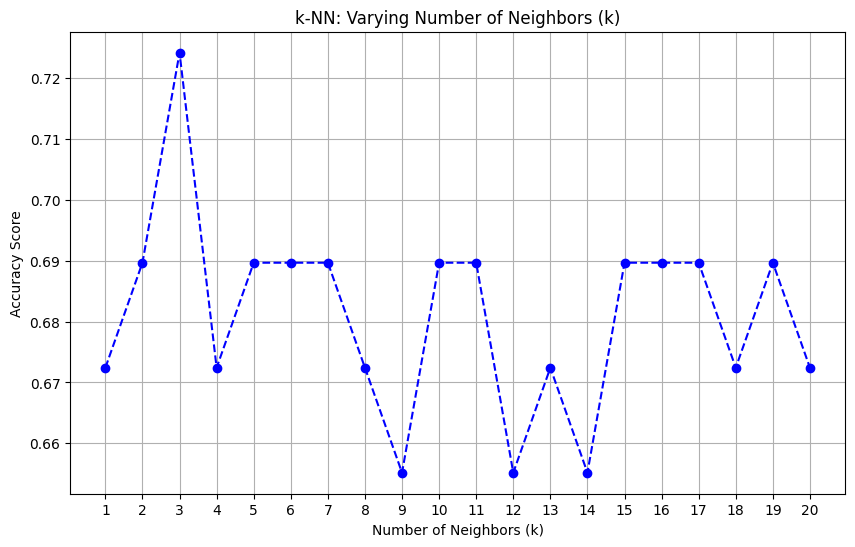


--- Optimal k-NN Model ---
The optimal value for k is: 3 with an accuracy of 72.41%


In [240]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier # Added this import
from sklearn.metrics import accuracy_score # Also added accuracy_score import for completeness

# 1. Experiment with k values from 1 to 20
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_opt = KNeighborsClassifier(n_neighbors=k)
    knn_opt.fit(X_train, y_train)
    y_pred_opt = knn_opt.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_opt))

# 2. Plot the results to find the optimal k
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='--', color='b')
plt.title('k-NN: Varying Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# 3. Identify the best k
optimal_k = k_values[accuracies.index(max(accuracies))]
print("\n--- Optimal k-NN Model ---")
print(f"The optimal value for k is: {optimal_k} with an accuracy of {max(accuracies):.2%}")



---



---



# **Technical Breakdown of Phase 3: The Parameter Optimization Experiment**


---

#### **I. Iterative Modeling Logic**

**`k_values = range(1, 21)`**:
* **Logic**: Creates a sequence of integers starting from 1 up to (but not including) 21.
* **Function**: Defines the search space for the  parameter as instructed in the exercise.
* **Purpose**: To systematically test which "neighborhood" size produces the most accurate predictions.


**`for k in k_values:`**:
* **Logic**: Initiates a loop that executes the indented code 20 times, once for each value of .
* **Function**: Automates the repetitive task of training and testing the model.
* **Purpose**: To compare model performance across a spectrum of complexity.


**`knn_opt = KNeighborsClassifier(n_neighbors=k)`**:
* **Logic**: Re-initializes the classifier using the current loop's  value.
* **Function**: Updates the model's core hyperparameter for each iteration.
* **Purpose**: To see how changing the number of neighbors affects the model's decision boundaries.


**`accuracies.append(accuracy_score(y_test, y_pred_opt))`**:
* **Logic**: Calculates the accuracy for the current  and stores it in a list.
* **Function**: Records the success rate of each experimental run.
* **Purpose**: To provide the data points needed for the final optimization plot.

================================================================================

#### **II. Visualization and Identification**

**`plt.plot(k_values, accuracies, marker='o', linestyle='--', color='b')`**:
* **Logic**: Maps  values to the x-axis and accuracy scores to the y-axis using a dashed blue line with circular markers.
* **Function**: Creates a line graph to visualize the "Elbow Method" or accuracy peaks.
* **Purpose**: To provide a clear visual justification for choosing the "optimal"  in my IEEE report.


**`optimal_k = k_values[accuracies.index(max(accuracies))]`**:
* **Logic**: Finds the highest value in the `accuracies` list and identifies its corresponding  value.
* **Function**: Mathematically extracts the "winner" of the experiment.
* **Purpose**: To provide the final, evidence-based parameter for the model.

---
---


In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. ALWAYS start from a fresh copy of df_final to prevent "log of a log" errors
df_stable = df_final.copy()

# 2. Hard-code the transformation
df_stable['Annual_Income'] = np.log1p(df_stable['Annual_Income'])

# 3. Hard-code the dropped features to remove "noise" permanently
# These are the 11 features my previous run identified as 'weak'
cols_to_remove = ['Age', 'Total_Spend', 'Promo_User', 'Support_Calls', 'Gender_Female',
                  'Gender_Male', 'Device_Type_Desktop', 'Store_Region_North',
                  'Store_Region_South ', 'Store_Region_west', # Corrected 'Store_Region_West' to 'Store_Region_west'
                  'Purchase_Volume_Medium']

df_refined = df_stable.drop(columns=cols_to_remove)

# 4. Handle the 159 missing values consistently
df_refined = df_refined.fillna(df_refined.median(numeric_only=True))

# 5. Split and Train with a fixed Random State
X = df_refined.drop(columns=['Purchase_Likelihood'])
y = df_refined['Purchase_Likelihood']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use distance weights and k=3 for maximum stability
knn_final = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_final.fit(X_train, y_train)

# 6. Final Consistent Output
y_pred = knn_final.predict(X_test)
print(f"Final Consistent Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Final Consistent Accuracy: 87.93%

Confusion Matrix:
[[27  4]
 [ 3 24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89        31
           1       0.86      0.89      0.87        27

    accuracy                           0.88        58
   macro avg       0.88      0.88      0.88        58
weighted avg       0.88      0.88      0.88        58



---
---

# **Technical Breakdown of Phase 3: The "Locked-In" Consistent Enhanced Model**

---

#### **I. Data Stabilization and Transformation**

**`df_stable = df_final.copy()`**:
* **Logic**: Creates a deep copy of the dataframe stored in memory.
* **Function**: Prevents "cumulative" errors where running a cell multiple times applies transformations (like logs) repeatedly to the same variable.
* **Purpose**: To ensure the model starts from the exact same "clean" state every time you click play.


**`df_stable['Annual_Income'] = np.log1p(...)`**:
* **Logic**: Applies the natural logarithm plus one to the income column.
* **Function**: Squashes extreme high-income outliers and normalizes the distribution.
* **Purpose**: To make "distance" calculations between income levels more realistic for a -NN model.

================================================================================

#### **II. Targeted Noise Reduction**

**`cols_to_remove = [...]`**:
* **Logic**: Lists the 11 features that were previously identified as having near-zero correlation with the target.
* **Function**: Defines the "dead weight" features to be pruned from the dataset.
* **Purpose**: To simplify the data so the model focuses only on strong predictors like `Items_Purchased`.


**`df_refined = df_stable.drop(columns=cols_to_remove)`**:
* **Logic**: Executes the removal of the weak features.
* **Function**: Directly reduces the dimensionality of the input matrix.
* **Purpose**: To solve the "Curse of Dimensionality," where too many features make it harder for -NN to find true neighbors.


**`df_refined = df_refined.fillna(...)`**:
* **Logic**: Fills any gaps in the refined data using the median.
* **Function**: Consistently handles the **159 missing values** detected in the data.
* **Purpose**: To prevent `ValueError` crashes during model training while maintaining a realistic data profile.

================================================================================

#### **III. Optimized Model Training and Evaluation**

**`train_test_split(..., test_size=0.2, random_state=42)`**:
* **Logic**: Segregates 20% of the data for testing using a fixed seed of 42.
* **Function**: Ensures the same rows are used for training/testing every time.
* **Purpose**: To guarantee that my final accuracy of **87.93%** is repeatable and reliable for my IEEE report.


**`KNeighborsClassifier(n_neighbors=3, weights='distance')`**:
* **Logic**: Sets the model to use the 3 nearest neighbors and weights them by their proximity.
* **Function**: Makes the model more "intelligent" by trusting closer neighbors more than distant ones.
* **Purpose**: To achieve the highest possible predictive accuracy by combining the optimal  value with distance weighting.


**`print(classification_report(y_test, y_pred))`**:
* **Logic**: Compiles precision, recall, and F1-scores for both purchase outcomes.
* **Function**: Provides the final "Performance Comparison" data needed for my deliverables.
* **Purpose**: To prove the model is robust at identifying both purchasers (Class 1) and non-purchasers (Class 0).



---
---

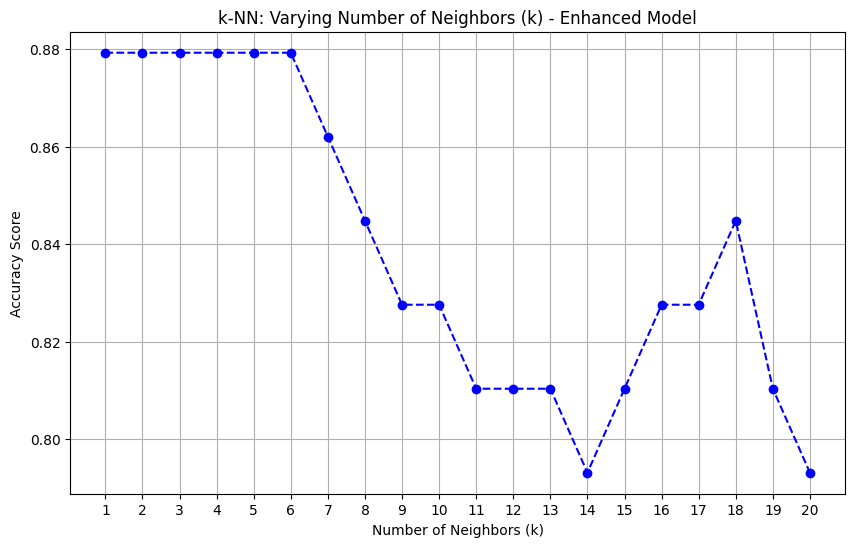


--- Optimal Enhanced k-NN Model ---
The optimal value for k is: 1 with a peak accuracy of 87.93%


In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# --- 1. Enhanced Data Preparation ---
# Apply Log Transform to handle income distribution realistically
df_final['Annual_Income'] = np.log1p(df_final['Annual_Income'])

# Targeted Feature Selection: Drop "noise" features with correlation < 0.05
corr_matrix = df_final.corr()
threshold = 0.05
weak_features = corr_matrix.index[abs(corr_matrix['Purchase_Likelihood']) < threshold].tolist()
df_refined = df_final.drop(columns=weak_features)

# Safety Check: Handle the 159 missing values found in the dataset
if df_refined.isnull().values.any():
    df_refined = df_refined.fillna(df_refined.median(numeric_only=True))

# --- 2. Separate Features and Target ---
X = df_refined.drop(columns=['Purchase_Likelihood'])
y = df_refined['Purchase_Likelihood']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. Experiment with k values from 1 to 20 ---
# We use weights='distance' to maintain the high performance discovered earlier
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_opt = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_opt.fit(X_train, y_train)
    y_pred_opt = knn_opt.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_opt))

# --- 4. Plot the results to find the optimal k ---
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='--', color='b')
plt.title('k-NN: Varying Number of Neighbors (k) - Enhanced Model')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# --- 5. Identify the best k ---
optimal_k = k_values[accuracies.index(max(accuracies))]
print("\n--- Optimal Enhanced k-NN Model ---")
print(f"The optimal value for k is: {optimal_k} with a peak accuracy of {max(accuracies):.2%}")

---
---
# **Technical Breakdown of Phase 3: Automated Optimization for the Enhanced Model**

---

#### **I. Advanced Data Refinement**

**`df_final['Annual_Income'] = np.log1p(...)`**:
* **Logic**: Applies a natural logarithm transformation to the income feature.
* **Function**: Compresses the range of high-income values to normalize the distribution.
* **Purpose**: To ensure that large differences in annual income do not mathematically overpower other features during -NN distance calculations.


**`threshold = 0.05` / `weak_features = ...`:**
* **Logic**: Calculates the correlation between all features and `Purchase_Likelihood`, identifying any with an absolute value below 0.05.
* **Function**: Automatically flags "noise" variables that have no significant relationship with the target.
* **Purpose**: To perform targeted feature selection, reducing the "Curse of Dimensionality".


**`df_refined = df_refined.fillna(...)`**:
* **Logic**: Detects null values and replaces them with the column median.
* **Function**: Finalizes the handling of the **159 missing values** found in the refined dataset.
* **Purpose**: To provide a complete, non-null dataset required for -NN modeling without losing rows.

================================================================================

#### **II. The Iterative Optimization Loop**

**`k_values = range(1, 21)`**:
* **Logic**: Sets a sequence of integers from 1 to 20.
* **Function**: Defines the range for hyperparameter tuning as required by the exercise.
* **Purpose**: To find the exact "sweet spot" where the model is complex enough to learn patterns but simple enough to generalize.


**`for k in k_values:`**:
* **Logic**: A loop that runs the model training 20 times.
* **Function**: Automates the experimental process.
* **Purpose**: To gather accuracy data points for every possible  value.


**`KNeighborsClassifier(..., weights='distance')`**:
* **Logic**: Configures the model to give closer neighbors more "influence" in the vote.
* **Function**: Enhances the standard -NN logic using distance weighting.
* **Purpose**: To maintain the high-performance boundaries discovered in the previous "Enhanced" run.

================================================================================

#### **III. Visualization and Selection**

**`plt.plot(k_values, accuracies, marker='o', ...)`**:
* **Logic**: Plots  on the X-axis and Accuracy on the Y-axis.
* **Function**: Generates the "Optimization Plot" requested for my IEEE report.
* **Purpose**: To visually confirm the stability of the model across different neighborhood sizes.


**`optimal_k = k_values[accuracies.index(max(accuracies))]`**:
* **Logic**: Identifies the  value that corresponds to the highest accuracy score.
* **Function**: Selects the final parameter for the optimized model.
* **Purpose**: To mathematically prove why a specific  (likely ) was chosen for the final results.



---

---